# Author : Prashanta Pal

# Model : STOCK PRICE PREDICTION MODEL BY **LSTM**

In [62]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [63]:
# Download stock data
ticket = "RELIANCE.NS"

data = yf.download(ticket, period='5y', interval='1d')

# Save dataset to CSV file
data.to_csv('reliance.csv')
print(data.head())

/tmp/ipykernel_794/984953752.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticket, period='5y', interval='1d')
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-05-26  893.282288  897.567245  891.128535  895.526772     7480204
2021-05-27  896.025513  903.688471  889.745478  893.395614    26819294
2021-05-28  949.847839  954.472816  902.328252  902.328252    56469931
2021-05-31  979.547607  993.785344  945.426921  953.112547    59124142
2021-06-01  983.447021  998.455586  973.290113  982.132042    28013832


In [64]:
# Removing Header by [ header=0 ]
df=pd.read_csv('reliance.csv',header=0)
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-26,893.2822875976562,897.5672452840586,891.1285347593667,895.5267721091835,7480204
3,2021-05-27,896.0255126953125,903.6884705135559,889.7454781714291,893.395613685115,26819294
4,2021-05-28,949.8478393554688,954.472815743996,902.3282518740783,902.3282518740783,56469931


In [65]:
# Remove first 2 rows

df=df.iloc[2:].copy()
df

,Price,Close,High,Low,Open,Volume
2,2021-05-26,893.2822875976562,897.5672452840586,891.1285347593667,895.5267721091835,7480204
3,2021-05-27,896.0255126953125,903.6884705135559,889.7454781714291,893.395613685115,26819294
4,2021-05-28,949.8478393554688,954.472815743996,902.3282518740783,902.3282518740783,56469931
5,2021-05-31,979.547607421875,993.7853440323877,945.4269209884944,953.1125474236037,59124142
6,2021-06-01,983.447021484375,998.4555855632798,973.290112651038,982.1320420491826,28013832
...,...,...,...,...,...,...
1235,2026-05-20,1359.699951171875,1362.9000244140625,1312.5999755859375,1318.699951171875,13248515
1236,2026-05-21,1349.5999755859375,1370.9000244140625,1345.199951171875,1367.199951171875,17150630
1237,2026-05-22,1354.5,1367.4000244140625,1349.0999755859375,1350.0,7105813
1238,2026-05-25,1367.0,1371.0999755859375,1357.0,1366.800048828125,6750071


In [66]:
# Rename columns

df.rename(columns={'Price':'Date'},inplace=True)
df

,Date,Close,High,Low,Open,Volume
2,2021-05-26,893.2822875976562,897.5672452840586,891.1285347593667,895.5267721091835,7480204
3,2021-05-27,896.0255126953125,903.6884705135559,889.7454781714291,893.395613685115,26819294
4,2021-05-28,949.8478393554688,954.472815743996,902.3282518740783,902.3282518740783,56469931
5,2021-05-31,979.547607421875,993.7853440323877,945.4269209884944,953.1125474236037,59124142
6,2021-06-01,983.447021484375,998.4555855632798,973.290112651038,982.1320420491826,28013832
...,...,...,...,...,...,...
1235,2026-05-20,1359.699951171875,1362.9000244140625,1312.5999755859375,1318.699951171875,13248515
1236,2026-05-21,1349.5999755859375,1370.9000244140625,1345.199951171875,1367.199951171875,17150630
1237,2026-05-22,1354.5,1367.4000244140625,1349.0999755859375,1350.0,7105813
1238,2026-05-25,1367.0,1371.0999755859375,1357.0,1366.800048828125,6750071


In [67]:
# Converting Date in DateTime Datatype

df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)
df=df[["Close"]]
df

,Close
Date,
2021-05-26,893.2822875976562
2021-05-27,896.0255126953125
2021-05-28,949.8478393554688
2021-05-31,979.547607421875
2021-06-01,983.447021484375
...,...
2026-05-20,1359.699951171875
2026-05-21,1349.5999755859375
2026-05-22,1354.5


In [68]:
df['Close']=pd.to_numeric(df['Close'],errors='coerce')

/tmp/ipykernel_794/1317994567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Close']=pd.to_numeric(df['Close'],errors='coerce')


In [69]:
df.dropna(inplace=True)

/tmp/ipykernel_794/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [70]:
df.to_csv('reliance2.csv')

In [71]:
df

,Close
Date,
2021-05-26,893.282288
2021-05-27,896.025513
2021-05-28,949.847839
2021-05-31,979.547607
2021-06-01,983.447021
...,...
2026-05-20,1359.699951
2026-05-21,1349.599976
2026-05-22,1354.500000


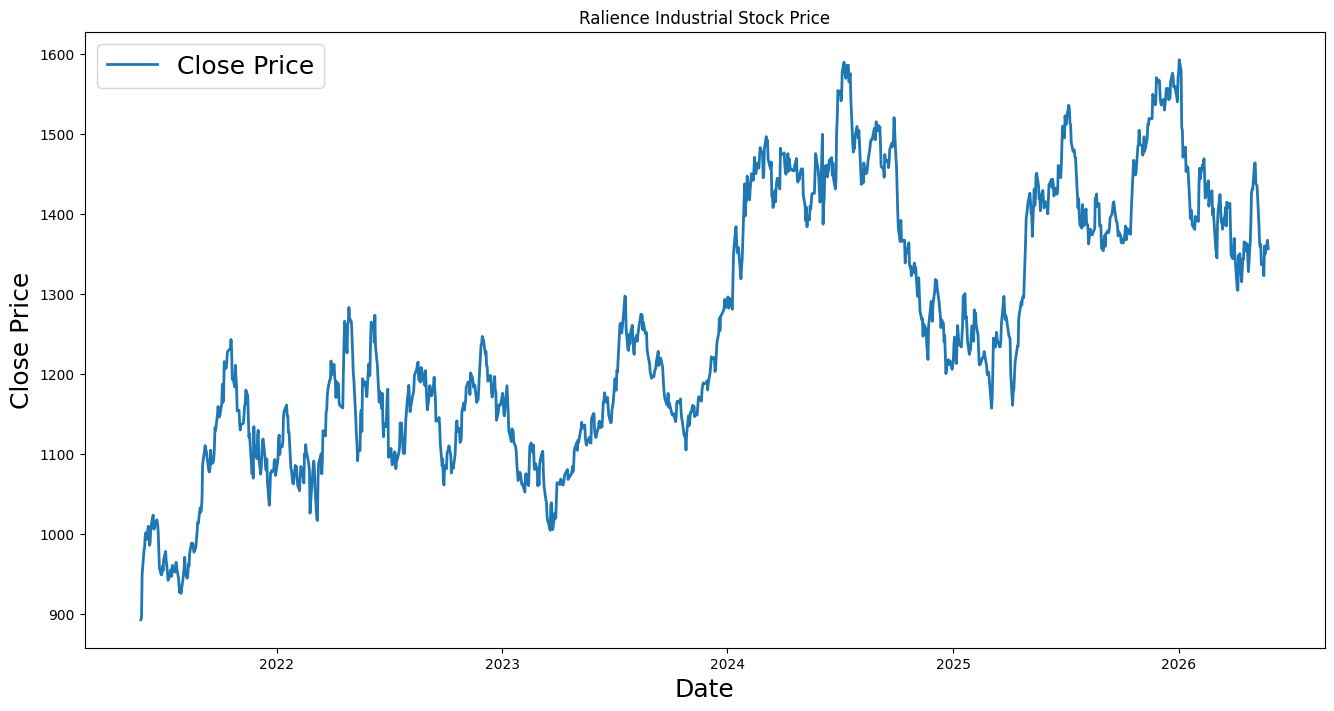

In [72]:
# Plot Data in Graph

plt.figure(figsize=(16,8))
plt.plot(df["Close"],label="Close Price",linewidth=2)
plt.title("Ralience Industrial Stock Price")
plt.xlabel("Date",fontsize=18)
plt.ylabel("Close Price",fontsize=18)
plt.legend(fontsize=18)

# Scaling

In [73]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(df)

In [74]:
def create_sequence(data, time_step=60):

    X, y = [], []

    for i in range(time_step, len(data)):

        # previous 60 days input
        X.append(data[i-time_step:i, 0])

        # next day target
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [75]:
TIME_STEP=60
X,y=create_sequence(scaled_data,TIME_STEP)
X=X.reshape(X.shape[0],X.shape[1],1)      # [samples, time_steps, features]

In [76]:
X = torch.tensor(X, dtype=torch.float32)

y = torch.tensor(y, dtype=torch.float32)

In [77]:
train_size=int(len(X)*0.8)
X_train,X_test=X[:train_size],X[train_size:]
y_train_y_test=y[:train_size],y[train_size:]

# LSTM Cell

In [78]:
class LSTMmodel(nn.Module):
  def __init__(self):
    super(LSTMmodel,self).__init__()
    self.hidden_size=50               # num of neurons in NN
    self.num_layers=2
    self.lstm=nn.LSTM(
        input_size=1,
        hidden_size=self.hidden_size,
        num_layers=self.num_layers,
        batch_first=True
    )
    self.fc=nn.Linear(self.hidden_size,1)

  def forward(self, x):

    h0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size)

    c0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size)

    out, _ = self.lstm(x, (h0, c0))

    out = out[:, -1, :]

    out = self.fc(out)

    return out

In [79]:
model=LSTMmodel()

In [80]:
epochs=20
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

#Training Loop

In [81]:
for epoch in range(epochs):
  model.train()
  output=model(X)
  loss = criterion(output.squeeze(), y)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

Epoch 1/20, Loss: 0.24911800026893616
Epoch 2/20, Loss: 0.23287896811962128
Epoch 3/20, Loss: 0.2171861231327057
Epoch 4/20, Loss: 0.20192505419254303
Epoch 5/20, Loss: 0.18700720369815826
Epoch 6/20, Loss: 0.17234013974666595
Epoch 7/20, Loss: 0.15782500803470612
Epoch 8/20, Loss: 0.14336980879306793
Epoch 9/20, Loss: 0.12890872359275818
Epoch 10/20, Loss: 0.1144227609038353
Epoch 11/20, Loss: 0.0999596118927002
Epoch 12/20, Loss: 0.08566004037857056
Epoch 13/20, Loss: 0.07180248200893402
Epoch 14/20, Loss: 0.058880388736724854
Epoch 15/20, Loss: 0.04772749915719032
Epoch 16/20, Loss: 0.03968878462910652
Epoch 17/20, Loss: 0.036701884120702744
Epoch 18/20, Loss: 0.040473200380802155
Epoch 19/20, Loss: 0.048680972307920456
Epoch 20/20, Loss: 0.05400067940354347


In [82]:
model.eval()

with torch.no_grad():

    predicted = model(X)

    predicted = predicted.numpy()

    predicted = scaler.inverse_transform(predicted)

    actual = scaler.inverse_transform(
        y.reshape(-1,1)
    )

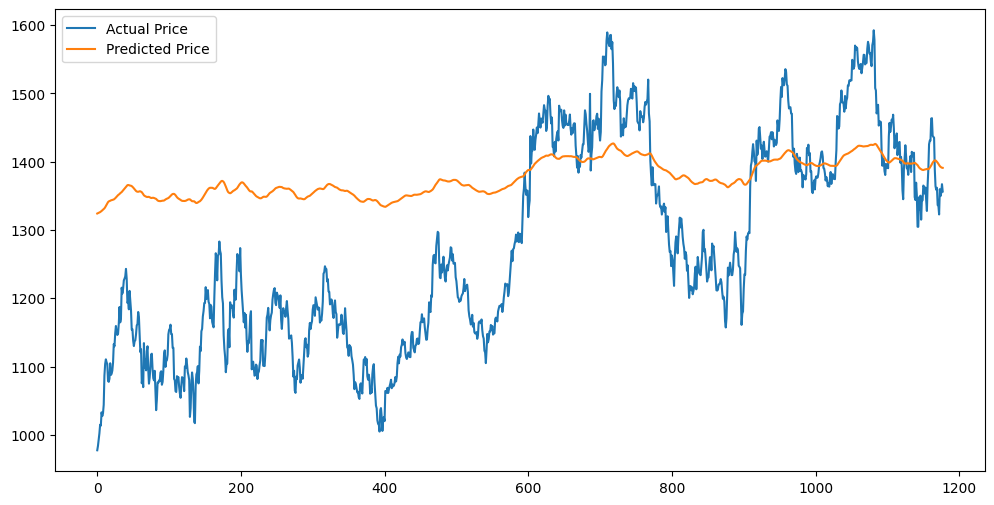

In [83]:
plt.figure(figsize=(12,6))

plt.plot(actual, label='Actual Price')

plt.plot(predicted, label='Predicted Price')

plt.legend()

plt.show()

# FUTURE STOCK PREDICTION

In [84]:
last_60_days = scaled_data[-60:]

X_test = np.array([last_60_days])

X_test = X_test.reshape(1,60,1)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

In [85]:
model.eval()

with torch.no_grad():

    future_price = model(X_test)

In [86]:
future_price = scaler.inverse_transform(
    future_price.numpy()
)

print(future_price)

[[1390.7755]]
